In [1]:
import torch 
import lightning as pl
from contrail_segmentation.models.masked_unet import PatchMasker, Masker, MaskedUNET
from segmentation_models_pytorch import Unet
from functools import partial
from hydra.utils import instantiate
import yaml

In [ ]:
x = torch.randn((8, 3, 256, 256))
masker = Masker()


In [6]:
masker(x).mean(dim=(1, 2)).mean()

tensor(0.4974, grad_fn=<MeanBackward0>)

In [2]:
model = MaskedUNET.load_from_checkpoint(
    '../checkpoints/masked_resnet50_best-contrail_seed0-v1.ckpt', weights_only=False
)

FileNotFoundError: [Errno 2] No such file or directory: 'c:/Users/garga/Documents/Uni/DSAIT4125/contrail-segmentation/notebooks/../checkpoints/masked_resnet50_best-contrail_seed0-v1.ckpt'

In [7]:
import numpy as np
import goes2go as goes
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from matplotlib import animation
from IPython import display

data_dir = '../data/train'
meta_path = '../data/train_metadata.csv'
metadata = pd.read_csv(meta_path)

In [8]:
def get_band_images(idx: str, parent_folder: str, band: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'band_{band}.npy'))

def get_mask(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_pixel_masks.npy'))

def get_mask_ind(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_individual_masks.npy'))

_T11_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)

def normalize_range(data, bounds):
    return (data - bounds[0]) / (bounds[1] - bounds[0])

def fake_color_img(idx, parent_folder, get_mask_frame_only=False):
    
    band11 = get_band_images(idx, parent_folder, '11')
    band14 = get_band_images(idx, parent_folder, '14')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band11 = band11[:,:,4]
        band14 = band14[:,:,4]
        band15 = band15[:,:,4]

    r = normalize_range(band15 - band14, _TDIFF_BOUNDS)
    g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
    b = normalize_range(band14, _T11_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color

In [ ]:
idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

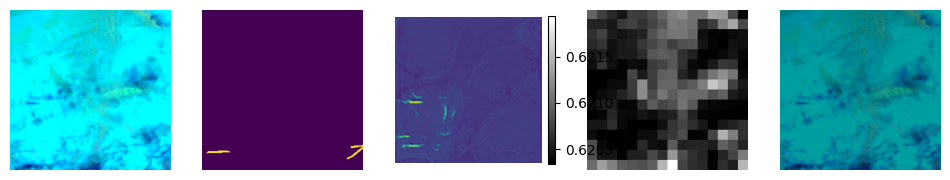

In [ ]:
input_img = torch.from_numpy(example_img).unsqueeze(0).permute(0, 3, 1, 2).to('cuda')
out = model(input_img, return_mask=True)

fig, axes = plt.subplots(1, 5, figsize=(12, 8))
axes[0].imshow(example_img)
axes[0].axis('off')
axes[1].imshow(get_mask(record_id, data_dir))
axes[1].axis('off')
axes[2].imshow(out[0].detach().cpu().numpy().squeeze())
axes[2].axis('off')
im = axes[3].imshow(out[1].detach().cpu().numpy().squeeze(), cmap='gray')
axes[3].axis('off')
axes[4].imshow(out[1].detach().cpu().squeeze().unsqueeze(dim=-1).numpy()* example_img, cmap='gray')
axes[4].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

In [17]:
from torchvision.transforms.functional import gaussian_blur
import math
import cv2

import torch.nn.functional as F

def plateau_cloud(mask, dilation_size=25, blur_sigma=30):
    if mask.ndim == 3:
            mask = mask.unsqueeze(1)
            
    padding = dilation_size // 2
    thick_mask = F.max_pool2d(mask.float(), kernel_size=dilation_size, stride=1, padding=padding)
    
    k_size = int(math.ceil(4 * blur_sigma)) | 1 
    soft_targets = gaussian_blur(thick_mask, [k_size, k_size], sigma=[blur_sigma, blur_sigma])
    
    view_shape = soft_targets.shape
    flat_targets = soft_targets.view(view_shape[0], -1)
    max_per_sample = flat_targets.max(dim=1, keepdim=True)[0]
    
    soft_targets = flat_targets / (max_per_sample + 1e-8)
    
    return soft_targets.view(view_shape) 

def get_full_cloud_mask(mask, sigma=25.0, gamma=0.2):
    mask = mask.float()
    
    k_size = int(math.ceil(4 * sigma))
    if k_size % 2 == 0:
        k_size += 1
        
    with torch.no_grad():
        soft_targets = gaussian_blur(mask, [k_size, k_size], sigma=[sigma, sigma])

        max_val = soft_targets.max()
        if max_val > 0:
            soft_targets = soft_targets / max_val

        soft_targets = torch.pow(soft_targets, gamma)
        
    return soft_targets

def shift(img):
    shift_matrix = np.array([[1.0, 0.0, 0.5], [0.0, 1.0, 0.5]], dtype=np.float32)

    # Apply the affine transformation using cv2.warpAffine
    shifted_img = cv2.warpAffine(
        img,
        shift_matrix,
        (img.shape[1], img.shape[0]), # Keep the same size
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    return shifted_img.astype(img.dtype)

Text(0.5, 1.0, 'Original Image')

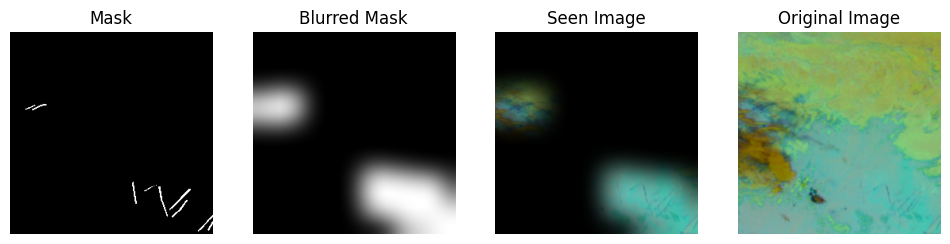

In [ ]:
idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

mask = torch.tensor(get_mask(record_id, data_dir)).unsqueeze(0).permute(0, 3, 1, 2).float()
soft_targets = plateau_cloud(mask, dilation_size=35, blur_sigma=15)
fig, axes = plt.subplots(1, 4, figsize=(12, 8))
axes[0].imshow(mask.squeeze().numpy(), cmap='gray')
axes[0].set_title('Mask')
axes[0].axis('off')
axes[1].imshow(soft_targets.squeeze().numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('Blurred Mask')
axes[2].imshow(soft_targets.squeeze().unsqueeze(-1).numpy() * example_img)
axes[2].axis('off')
axes[2].set_title('Seen Image')
axes[3].imshow(example_img)
axes[3].axis('off')

axes[3].set_title('Original Image')

Text(0.5, 1.0, 'Original Image')

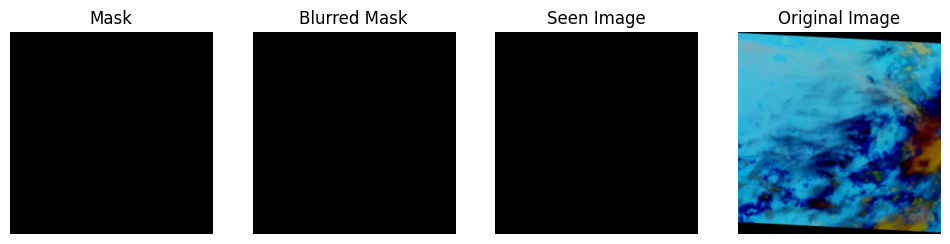

In [37]:
import albumentations as A
import cv2

train_transform = A.Compose([
        # A.Rotate(p=1), 
        A.RandomRotate90(p=0.1),
        A.OneOf([
            A.HorizontalFlip(p=0.1),
            A.VerticalFlip(p=0.75),
        ], p=1),
        A.Affine(
            scale=(0.9, 1.1),
            rotate=(-90, 90),
            translate_percent={"x": (-0.0, 0.0), "y": (-0.0, 0.0)},
            shear=(-0, 0),
            p=1,
            mask_interpolation=cv2.INTER_NEAREST
        ),
        # A.GaussianBlur(sigma_limit=0.5, p=0.25),
        # A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.15, p=0.3),
    ], additional_targets={'pixel_mask': 'mask'})

idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

pixel_mask = get_mask(record_id, data_dir)
augmented = train_transform(image=shift(example_img), pixel_mask=pixel_mask)
image_aug = augmented['image']
pixel_mask_aug = augmented['pixel_mask']

mask = torch.tensor(pixel_mask_aug).unsqueeze(0).permute(0, 3, 1, 2).float()
soft_targets = plateau_cloud(mask, dilation_size=35, blur_sigma=15)
fig, axes = plt.subplots(1, 4, figsize=(12, 8))
axes[0].imshow(mask.squeeze().numpy(), cmap='gray')
axes[0].set_title('Mask')
axes[0].axis('off')
axes[1].imshow(soft_targets.squeeze().numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('Blurred Mask')
axes[2].imshow(soft_targets.squeeze().unsqueeze(-1).numpy() * image_aug)
axes[2].axis('off')
axes[2].set_title('Seen Image')
axes[3].imshow(image_aug)
axes[3].axis('off')
axes[3].set_title('Original Image')

Text(0.5, 1.0, 'Original Image')

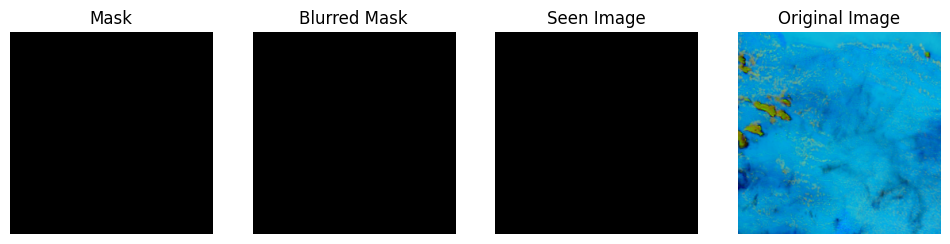

In [14]:
idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

mask = torch.tensor(get_mask(record_id, data_dir)).unsqueeze(0).permute(0, 3, 1, 2).float()
soft_targets = plateau_cloud(mask, dilation_size=35, blur_sigma=15)
fig, axes = plt.subplots(1, 4, figsize=(12, 8))
axes[0].imshow(mask.squeeze().numpy(), cmap='gray')
axes[0].set_title('Mask')
axes[0].axis('off')
axes[1].imshow(soft_targets.squeeze().numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('Blurred Mask')
axes[2].imshow(soft_targets.squeeze().unsqueeze(-1).numpy() * example_img)
axes[2].axis('off')
axes[2].set_title('Seen Image')
axes[3].imshow(example_img)
axes[3].axis('off')

axes[3].set_title('Original Image')

Text(0.5, 1.0, 'Original Image')

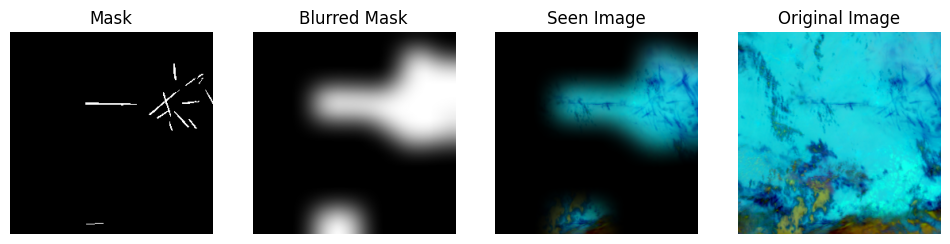

In [24]:
idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

mask = torch.tensor(get_mask(record_id, data_dir)).unsqueeze(0).permute(0, 3, 1, 2).float()
soft_targets = plateau_cloud(mask, dilation_size=35, blur_sigma=15)
fig, axes = plt.subplots(1, 4, figsize=(12, 8))
axes[0].imshow(mask.squeeze().numpy(), cmap='gray')
axes[0].set_title('Mask')
axes[0].axis('off')
axes[1].imshow(soft_targets.squeeze().numpy(), cmap='gray')
axes[1].axis('off')
axes[1].set_title('Blurred Mask')
axes[2].imshow(soft_targets.squeeze().unsqueeze(-1).numpy() * example_img)
axes[2].axis('off')
axes[2].set_title('Seen Image')
axes[3].imshow(example_img)
axes[3].axis('off')

axes[3].set_title('Original Image')